In [1]:
import pandas as pd
import os
from sqlalchemy import create_engine
import logging
import time

os.makedirs("logs", exist_ok=True)

logging.basicConfig(
    filename="logs/ingestion_db.log",
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(message)s",
    filemode="a"
)

engine = create_engine('sqlite:///inventory.db')

def ingest_db(df, table_name, engine):
    '''this function will ingest the dataframe into database table'''
    df.to_sql(table_name, con=engine, if_exists = 'replace', index=False)

def load_raw_data():
    '''this function will load CSVs as datafreame into ingest db'''
    start = time.time()
    for file in os.listdir('/kaggle/input/datasets/rajatd02/blinkit-data'):
        if '.csv' in file:
            df=pd.read_csv('/kaggle/input/datasets/rajatd02/blinkit-data/'+file)
            logging.info(f'Ingesting {file} in db')
            ingest_db(df, file[:-4], engine)
    end = time.time()
    total_time = (end-start)/60
    logging.info('----------Ingestion Complete----------')
    logging.info(f'Total Time Taken : {total_time} minutes')

if __name__ == '__main__':
    load_raw_data()

Exploratory Data Analyisis

In [2]:
import sqlite3

In [3]:
conn = sqlite3.connect('inventory.db')

In [4]:
import pandas as pd
tables = pd.read_sql_query("SELECT name FROM sqlite_master",conn)
tables

,name
0,purchase_prices
1,vendor_invoice
2,purchases
3,begin_inventory
4,end_inventory
5,sales


In [5]:
pd.read_sql("select count(*) as records from sales",conn)

,records
0,12825363


In [6]:
for table in tables['name']:
    print('-'*50, table, '-'*50)
    print('Count of records:', pd.read_sql(f"SELECT COUNT(*) as records FROM {table}", conn)['records'].values[0])

-------------------------------------------------- purchase_prices --------------------------------------------------
Count of records: 12261
-------------------------------------------------- vendor_invoice --------------------------------------------------
Count of records: 5543
-------------------------------------------------- purchases --------------------------------------------------
Count of records: 2372474
-------------------------------------------------- begin_inventory --------------------------------------------------
Count of records: 206529
-------------------------------------------------- end_inventory --------------------------------------------------
Count of records: 224489
-------------------------------------------------- sales --------------------------------------------------
Count of records: 12825363


In [7]:
for table in tables['name']:
    print('-'*50, table, '-'*50)
    print('Count of records:', pd.read_sql(f"SELECT COUNT(*) as records FROM {table}", conn)['records'].values[0])
    display(pd.read_sql(f"select * from {table} limit 5",conn))

-------------------------------------------------- purchase_prices --------------------------------------------------
Count of records: 12261


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


-------------------------------------------------- vendor_invoice --------------------------------------------------
Count of records: 5543


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


-------------------------------------------------- purchases --------------------------------------------------
Count of records: 2372474


...

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


-------------------------------------------------- end_inventory --------------------------------------------------
Count of records: 224489


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


-------------------------------------------------- sales --------------------------------------------------
Count of records: 12825363


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY


In [8]:
purchase_price = pd.read_sql(f"select * from purchase_prices where VendorNumber = 1128",conn)
purchase_price

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
1,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
2,171,Gentleman Jack,49.99,1750mL,1750,1,36.76,1128,BROWN-FORMAN CORP
3,809,Southern Comfort,17.99,1000mL,1000,1,13.13,1128,BROWN-FORMAN CORP
4,811,Jack Daniels No 7 Black,29.99,1000mL,1000,1,19.84,1128,BROWN-FORMAN CORP
...,...,...,...,...,...,...,...,...,...
137,1260,Old Forester Birthday 2016,89.99,750mL,750,1,71.99,1128,BROWN-FORMAN CORP
138,1279,Woodford Rsv MC Brandy Fnish,99.99,750mL,750,1,77.51,1128,BROWN-FORMAN CORP
139,1801,Jack Daniels Tennesse Fire,12.99,375mL,375,1,9.62,1128,BROWN-FORMAN CORP
140,2033,Canadian Mist,7.99,750mL,750,1,5.96,1128,BROWN-FORMAN CORP


In [9]:
vendor_invoice = pd.read_sql(f"select * from vendor_invoice where VendorNumber = 1128",conn)
vendor_invoice

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,1128,BROWN-FORMAN CORP,2024-01-09,8150,2023-12-23,2024-02-19,4684,65403.57,1808.77,None
1,1128,BROWN-FORMAN CORP,2024-01-15,8210,2023-12-27,2024-02-25,23351,298902.89,1494.51,Frank Delahunt
2,1128,BROWN-FORMAN CORP,2024-01-26,8358,2024-01-06,2024-02-18,11443,138035.44,690.18,None
3,1128,BROWN-FORMAN CORP,2024-02-02,8457,2024-01-13,2024-02-29,12899,142492.97,755.21,None
4,1128,BROWN-FORMAN CORP,2024-02-06,8517,2024-01-18,2024-03-15,23217,335055.84,1708.78,Frank Delahunt
5,1128,BROWN-FORMAN CORP,2024-02-15,8689,2024-01-29,2024-03-24,18863,250689.87,1328.66,Frank Delahunt
6,1128,BROWN-FORMAN CORP,2024-02-23,8742,2024-02-02,2024-03-17,11876,165219.61,743.49,None
7,1128,BROWN-FORMAN CORP,2024-02-23,8838,2024-02-09,2024-03-25,17574,203550.59,956.69,None
8,1128,BROWN-FORMAN CORP,2024-03-02,8945,2024-02-16,2024-04-11,27342,313177.52,1691.16,Frank Delahunt
9,1128,BROWN-FORMAN CORP,2024-03-07,9017,2024-02-21,2024-04-21,15019,195521.15,1036.26,None


In [10]:
sales = pd.read_sql(f"select * from sales where VendorNo = 1128",conn)
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1051,1,1051,Woodford Reserve MC 1838,750mL,1,99.99,99.99,2024-01-04,750.0,1,0.79,1128,BROWN-FORMAN CORP
1,1_HARDERSFIELD_1051,1,1051,Woodford Reserve MC 1838,750mL,1,99.99,99.99,2024-01-23,750.0,1,0.79,1128,BROWN-FORMAN CORP
2,1_HARDERSFIELD_1060,1,1060,Jack Daniels Bruins Glass Pk,Liter,2,55.98,27.99,2024-01-01,1000.0,1,2.10,1128,BROWN-FORMAN CORP
3,1_HARDERSFIELD_1060,1,1060,Jack Daniels Bruins Glass Pk,Liter,1,27.99,27.99,2024-01-02,1000.0,1,1.05,1128,BROWN-FORMAN CORP
4,1_HARDERSFIELD_1060,1,1060,Jack Daniels Bruins Glass Pk,Liter,1,31.99,31.99,2024-01-11,1000.0,1,1.05,1128,BROWN-FORMAN CORP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353460,9_BLACKPOOL_8910,9,8910,Finlandia Vodka,50mL,35,34.65,0.99,2024-12-26,50.0,1,1.84,1128,BROWN-FORMAN CORP
353461,9_BLACKPOOL_8910,9,8910,Finlandia Vodka,50mL,8,7.92,0.99,2024-12-27,50.0,1,0.42,1128,BROWN-FORMAN CORP
353462,9_BLACKPOOL_8910,9,8910,Finlandia Vodka,50mL,9,8.91,0.99,2024-12-29,50.0,1,0.47,1128,BROWN-FORMAN CORP
353463,9_BLACKPOOL_8910,9,8910,Finlandia Vodka,50mL,25,24.75,0.99,2024-12-30,50.0,1,1.31,1128,BROWN-FORMAN CORP


In [11]:
pd.read_sql("PRAGMA table_info(purchases)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,InventoryId,TEXT,0,None,0
1,1,Store,BIGINT,0,None,0
2,2,Brand,BIGINT,0,None,0
3,3,Description,TEXT,0,None,0
4,4,Size,TEXT,0,None,0
5,5,VendorNumber,BIGINT,0,None,0
6,6,VendorName,TEXT,0,None,0
7,7,PONumber,BIGINT,0,None,0
8,8,PODate,TEXT,0,None,0
9,9,ReceivingDate,TEXT,0,None,0


In [12]:
purchases = pd.read_sql("SELECT * FROM purchases", conn)
purchases.groupby(['Brand','PurchasePrice'])[['Quantity','Dollars']].sum()

,,Quantity,Dollars
Brand,PurchasePrice,,
58,9.28,3550,32944.00
60,7.40,1633,12084.20
61,10.60,312,3307.20
62,28.67,3200,91744.00
63,30.46,2855,86963.30
...,...,...,...
90089,77.92,32,2493.44
90090,448.27,6,2689.62
90604,78.42,118,9253.56


In [13]:
print(purchases.columns.tolist())

['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber', 'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification']


In [14]:
purchase_price

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
1,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
2,171,Gentleman Jack,49.99,1750mL,1750,1,36.76,1128,BROWN-FORMAN CORP
3,809,Southern Comfort,17.99,1000mL,1000,1,13.13,1128,BROWN-FORMAN CORP
4,811,Jack Daniels No 7 Black,29.99,1000mL,1000,1,19.84,1128,BROWN-FORMAN CORP
...,...,...,...,...,...,...,...,...,...
137,1260,Old Forester Birthday 2016,89.99,750mL,750,1,71.99,1128,BROWN-FORMAN CORP
138,1279,Woodford Rsv MC Brandy Fnish,99.99,750mL,750,1,77.51,1128,BROWN-FORMAN CORP
139,1801,Jack Daniels Tennesse Fire,12.99,375mL,375,1,9.62,1128,BROWN-FORMAN CORP
140,2033,Canadian Mist,7.99,750mL,750,1,5.96,1128,BROWN-FORMAN CORP


In [15]:
vendor_invoice['PONumber'].nunique()

55

In [16]:
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1051,1,1051,Woodford Reserve MC 1838,750mL,1,99.99,99.99,2024-01-04,750.0,1,0.79,1128,BROWN-FORMAN CORP
1,1_HARDERSFIELD_1051,1,1051,Woodford Reserve MC 1838,750mL,1,99.99,99.99,2024-01-23,750.0,1,0.79,1128,BROWN-FORMAN CORP
2,1_HARDERSFIELD_1060,1,1060,Jack Daniels Bruins Glass Pk,Liter,2,55.98,27.99,2024-01-01,1000.0,1,2.10,1128,BROWN-FORMAN CORP
3,1_HARDERSFIELD_1060,1,1060,Jack Daniels Bruins Glass Pk,Liter,1,27.99,27.99,2024-01-02,1000.0,1,1.05,1128,BROWN-FORMAN CORP
4,1_HARDERSFIELD_1060,1,1060,Jack Daniels Bruins Glass Pk,Liter,1,31.99,31.99,2024-01-11,1000.0,1,1.05,1128,BROWN-FORMAN CORP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353460,9_BLACKPOOL_8910,9,8910,Finlandia Vodka,50mL,35,34.65,0.99,2024-12-26,50.0,1,1.84,1128,BROWN-FORMAN CORP
353461,9_BLACKPOOL_8910,9,8910,Finlandia Vodka,50mL,8,7.92,0.99,2024-12-27,50.0,1,0.42,1128,BROWN-FORMAN CORP
353462,9_BLACKPOOL_8910,9,8910,Finlandia Vodka,50mL,9,8.91,0.99,2024-12-29,50.0,1,0.47,1128,BROWN-FORMAN CORP
353463,9_BLACKPOOL_8910,9,8910,Finlandia Vodka,50mL,25,24.75,0.99,2024-12-30,50.0,1,1.31,1128,BROWN-FORMAN CORP


In [17]:
sales.groupby('Brand')[['SalesDollars','SalesPrice', 'SalesQuantity']].sum()

,SalesDollars,SalesPrice,SalesQuantity
Brand,,,
62,119863.75,90154.51,3125
63,112249.22,88553.10,2778
165,17875.84,12539.68,616
171,338434.10,236839.04,6590
309,45.99,45.99,1
...,...,...,...
26949,192403.31,71154.05,8369
27138,2702.31,719.55,169
27907,479.88,159.96,12


In [18]:
vendor_invoice.shape

(55, 10)

In [19]:
vendor_invoice.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='object')

In [20]:
sales.groupby('Brand')[['SalesDollars','SalesPrice','SalesQuantity']].sum()

,SalesDollars,SalesPrice,SalesQuantity
Brand,,,
62,119863.75,90154.51,3125
63,112249.22,88553.10,2778
165,17875.84,12539.68,616
171,338434.10,236839.04,6590
309,45.99,45.99,1
...,...,...,...
26949,192403.31,71154.05,8369
27138,2702.31,719.55,169
27907,479.88,159.96,12


.The purchases table contains actual purchase data, including the date of purchase, products purchased by vendors, the amount paid and the uantity purchased.

.The purchase price column is derived from the purchase_price table, which provided product-wise actual and purchase prices, The combination of vendor and brand is unique in this table.

.The vendor_invoice table aggregrates data from the purhase table, summarizing quantity and dollar amounts, along with an additional columns for freight the table maintains uniqueness based on vendor and PG number.

.The sales table captures actual sales transaction, detailing the brands purchasesd by vendors, the quantity sold, the selling price, and the revenue earned.

As the data that we need for analysis is distributed in different tables, we need to create a summary table containing:

1. Purchase transaction made by vendors.
2. Sales transaction data
3. freight costs for each vendor
4. actual product price from vendors

In [21]:
freight_summary = pd.read_sql_query(
    """SELECT VendorNumber, SUM(Freight) as FreightCost
    from vendor_invoice
    GROUP BY 1""",conn
)
freight_summary

,VendorNumber,FreightCost
0,2,27.08
1,54,0.48
2,60,367.52
3,105,62.39
4,200,6.19
...,...,...
121,98450,856.02
122,99166,130.09
123,172662,178.34
124,173357,202.50


In [22]:
purchases.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber',
       'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate',
       'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification'],
      dtype='object')

In [23]:
purchase_price.columns

Index(['Brand', 'Description', 'Price', 'Size', 'Volume', 'Classification',
       'PurchasePrice', 'VendorNumber', 'VendorName'],
      dtype='object')

In [24]:
pd.read_sql_query("""
SELECT
    p.VendorNumber,
    p.VendorName,
    p.Brand,
    p.PurchasePrice,
    pp.Volume,
    pp.Price as ActualPrice,
    SUM(Quantity) as TotalPurchaseQuantity,
    SUM(Dollars) as TotalPurchaseDollars
FROM purchases p
JOIN purchase_prices pp
    ON p.Brand = pp.Brand
    WHERE p.PurchasePrice > 0
GROUP BY 
    p.VendorNumber,
    p.VendorName,
    p.Brand,
    p.PurchasePrice,
    pp.Volume,
    pp.Price
ORDER BY TotalPurchaseQuantity
""", conn)

,VendorNumber,VendorName,Brand,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars
0,54,AAPER ALCOHOL & CHEMICAL CO,990,105.07,3750,134.49,1,105.07
1,480,BACARDI USA INC,4357,7.46,750,9.99,1,7.46
2,480,BACARDI USA INC,5181,23.99,750,29.99,1,23.99
3,480,BACARDI USA INC,6916,11.10,200,14.99,1,11.10
4,516,BANFI PRODUCTS CORP,17172,4.10,750,5.99,1,4.10
...,...,...,...,...,...,...,...,...
10687,10000,MAJESTIC FINE WINES,6570,6.77,750,10.99,215668,1460072.36
10688,3960,DIAGEO NORTH AMERICA INC,3606,0.74,50,0.99,226085,167302.90
10689,8004,SAZERAC CO INC,5111,0.72,50,0.99,244654,176150.88
10690,3960,DIAGEO NORTH AMERICA INC,1892,0.72,50,0.99,254824,183473.28


In [25]:
sales.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity',
       'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification',
       'ExciseTax', 'VendorNo', 'VendorName'],
      dtype='object')

In [26]:
pd.read_sql_query("""
select VendorNo,
Brand,
SUM(SalesDollars) as TotalSalesDollars,
SUM(SalesPrice) as TotalSalesPrice,
SUM(SalesQuantity) as TotalSalesQuantity,
SUM(ExciseTax) as TotalExciseTax
FROM sales
Group BY VendorNo, Brand
ORDER BY 3
""",conn)

,VendorNo,Brand,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax
0,8004,5287,9.800000e-01,0.98,2,0.10
1,9206,2773,9.900000e-01,0.99,1,0.05
2,3252,3933,1.980000e+00,0.99,2,0.10
3,3924,9123,1.980000e+00,0.99,2,0.10
4,10050,3623,1.980000e+00,1.98,2,0.10
...,...,...,...,...,...,...
11267,3960,3545,4.223108e+06,545778.28,135838,249587.83
11268,3960,4261,4.475973e+06,420050.01,200412,368242.80
11269,17035,8068,4.538121e+06,461140.15,187140,343854.07
11270,4425,3405,4.819073e+06,561512.37,160247,294438.66


In [27]:
# start = time.time()
# final_table = pd.read_sql_query("""select
# pp.VendorNumber,
# pp.Brand,
# pp.Price as ActualPrice,
# pp.PurchasePrice,
# SUM(s.SalesQuantity) as TotalSalesQuantity,
# SUM(s.SalesDollars) as TotalSalesDollars,
# SUM(s.SalesPrice) as TotalSalesPrice,
# SUM(s.ExciseTax) as TotalExciseTax,
# SUM(vi.Quantity) as TotalPurchaseQuantity,
# SUM(vi.Dollars) as TotalPurchaseDollars,
# SUM(vi.Freight) as TotalFreightCost
# from purchase_prices as pp
# JOIN sales s
# on pp.VendorNumber = s.VendorNo
# and pp.Brand = S.Brand
# join vendor_invoice vi
# on pp.VendorNumber = vi.VendorNumber
# GROUP BY pp.VendorNumber, pp.Brand, pp.Price, pp.PurchasePrice
# """,conn)
# end = time.time()

Can broke the queries using cte and join them with cte to run it fast. 

In [28]:
import time

start = time.time()

# Pre-aggregate sales by VendorNo + Brand to avoid row explosion in the final join
# Pre-aggregate vendor_invoice by VendorNumber + Brand (if Brand exists) or just VendorNumber
# The root cause of slowness: vendor_invoice was joined only on VendorNumber,
# causing a cartesian product with every sale row per vendor.

final_table = pd.read_sql_query("""
WITH sales_agg AS (
    SELECT
        VendorNo,
        Brand,
        SUM(SalesQuantity)  AS TotalSalesQuantity,
        SUM(SalesDollars)   AS TotalSalesDollars,
        SUM(SalesPrice)     AS TotalSalesPrice,
        SUM(ExciseTax)      AS TotalExciseTax
    FROM sales
    GROUP BY VendorNo, Brand
),
invoice_agg AS (
    SELECT
        VendorNumber,
        SUM(Quantity) AS TotalPurchaseQuantity,
        SUM(Dollars)  AS TotalPurchaseDollars,
        SUM(Freight)  AS TotalFreightCost
    FROM vendor_invoice
    GROUP BY VendorNumber
)
SELECT
    pp.VendorNumber,
    pp.Brand,
    pp.Price          AS ActualPrice,
    pp.PurchasePrice,
    sa.TotalSalesQuantity,
    sa.TotalSalesDollars,
    sa.TotalSalesPrice,
    sa.TotalExciseTax,
    ia.TotalPurchaseQuantity,
    ia.TotalPurchaseDollars,
    ia.TotalFreightCost
FROM purchase_prices AS pp
JOIN sales_agg sa
    ON pp.VendorNumber = sa.VendorNo
    AND pp.Brand = sa.Brand
LEFT JOIN invoice_agg ia
    ON pp.VendorNumber = ia.VendorNumber
""", conn)

end = time.time()
print(f"Query completed in {end - start:.2f} seconds")
final_table.head()

Query completed in 18.67 seconds


,VendorNumber,Brand,ActualPrice,PurchasePrice,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,TotalFreightCost
0,8320,58,12.99,9.28,3446,43341.54,28145.64,2715.12,69127.0,624979.64,3151.92
1,1128,62,36.99,28.67,3125,119863.75,90154.51,2463.18,1006122.0,13529433.08,68601.68
2,1128,63,38.99,30.46,2778,112249.22,88553.10,2190.45,1006122.0,13529433.08,68601.68
3,9165,72,34.99,26.11,469,17325.31,12626.57,369.84,1077527.0,13210613.93,68054.70
4,7245,75,14.99,10.94,21,314.79,134.91,16.53,682042.0,7588029.90,38994.78


In [29]:
purchases.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber',
       'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate',
       'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification'],
      dtype='object')

In [30]:
vendor_sales_summary = pd.read_sql_query("""with FreightSummary AS (
SELECT VendorNumber,
SUM(Freight) as FreightCost
from vendor_invoice
group by VendorNumber),

PurchaseSummary AS (
select p.VendorNumber,
p.VendorName,
p.Brand,
p.Description,
p.PurchasePrice,
pp.Price as ActualPrice,
pp.Volume,
SUM(p.Quantity) AS TotalPurchaseQuantity,
SUM(p.Dollars) AS TotalPurchaseDollars
from purchases p
join purchase_prices as pp
on p.Brand = pp.Brand
where p.PurchasePrice > 0
GROUP BY 1,2,3,4,5,6,7
),

SalesSummary AS (
select VendorNo,
Brand,
SUM(SalesDollars) as TotalSalesDollars,
SUM(SalesPrice) as TotalSalesPrice,
SUM(SalesQuantity) as TotalSalesQuantity,
SUM(ExciseTax) as TotalExciseTax
FROM sales
Group BY VendorNo, Brand
)

SELECT 
ps.VendorNumber,
ps.VendorName,
ps.Brand,
ps.Description,
ps.PurchasePrice,
ps.ActualPrice,
ps.Volume,
ps.TotalPurchaseQuantity,
ps.TotalPurchaseDollars,
ss.TotalSalesQuantity,
ss.TotalSalesDollars,
ss.TotalSalesPrice,
ss.TotalExciseTax,
fs.FreightCost
from PurchaseSummary as ps
left join SalesSummary as ss
on ps.VendorNumber = ss.VendorNo
and ps.Brand = ss.Brand
left join FreightSummary as fs
on ps.VendorNumber = fs.VendorNumber
order by ps.TotalPurchaseDollars DESC
""", conn)

This query generates a vendor wise sales and puchases summary, which is valuable for:

1. The query involves heavy joins and aggregations on large datasets like sales and puchases.
2. Storing the pre-aggregated results avoids repeated expensive compulsions.
3. Helps in analyzing sales, purchases, and pricing for different vendors and brands.
4. Future Benefits of storing this data for faster Dashboarding & Reporting.
5. Instead of runing expensive queries each time, dashBoards, can fetch data quickly from final_table

In [31]:
vendor_sales_summary

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07


In [32]:
vendor_sales_summary.dtypes

VendorNumber               int64
VendorName                object
Brand                      int64
Description               object
PurchasePrice            float64
ActualPrice              float64
Volume                    object
TotalPurchaseQuantity      int64
TotalPurchaseDollars     float64
TotalSalesQuantity       float64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
dtype: object

In [33]:
vendor_sales_summary.isnull().sum()

VendorNumber               0
VendorName                 0
Brand                      0
Description                0
PurchasePrice              0
ActualPrice                0
Volume                     0
TotalPurchaseQuantity      0
TotalPurchaseDollars       0
TotalSalesQuantity       178
TotalSalesDollars        178
TotalSalesPrice          178
TotalExciseTax           178
FreightCost                0
dtype: int64

In [34]:
vendor_sales_summary['VendorName'].unique()

array(['BROWN-FORMAN CORP          ', 'MARTIGNETTI COMPANIES',
       'PERNOD RICARD USA          ', 'DIAGEO NORTH AMERICA INC   ',
       'BACARDI USA INC            ', 'JIM BEAM BRANDS COMPANY    ',
       'MAJESTIC FINE WINES        ', 'ULTRA BEVERAGE COMPANY LLP ',
       'STOLI GROUP,(USA) LLC      ', 'PROXIMO SPIRITS INC.       ',
       'MOET HENNESSY USA INC      ', 'CAMPARI AMERICA            ',
       'SAZERAC CO INC             ', 'CONSTELLATION BRANDS INC   ',
       'M S WALKER INC             ', 'SAZERAC NORTH AMERICA INC. ',
       'PALM BAY INTERNATIONAL INC ', 'REMY COINTREAU USA INC     ',
       'SIDNEY FRANK IMPORTING CO  ', 'E & J GALLO WINERY         ',
       'WILLIAM GRANT & SONS INC   ', 'HEAVEN HILL DISTILLERIES   ',
       'DISARONNO INTERNATIONAL LLC', 'EDRINGTON AMERICAS         ',
       'CASTLE BRANDS CORP.        ', 'SOUTHERN WINE & SPIRITS NE ',
       'STE MICHELLE WINE ESTATES  ', 'TRINCHERO FAMILY ESTATES   ',
       'MHW LTD                    ', 'W

In [35]:
vendor_sales_summary['Description'].unique()

array(['Jack Daniels No 7 Black', "Tito's Handmade Vodka",
       'Absolut 80 Proof', ..., 'Crown Royal Apple',
       'Concannon Glen Ellen Wh Zin', 'The Club Strawbry Margarita'],
      dtype=object)

In [36]:
vendor_sales_summary['Volume'] = vendor_sales_summary['Volume'].astype('float64')

In [37]:
vendor_sales_summary['VendorName'] = vendor_sales_summary['VendorName'].str.strip() 

In [38]:
vendor_sales_summary.fillna(0,inplace = True)

In [39]:
vendor_sales_summary['GrossProfit'] = vendor_sales_summary['TotalSalesDollars'] - vendor_sales_summary['TotalPurchaseDollars']

In [40]:
vendor_sales_summary[vendor_sales_summary['GrossProfit']<0]

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit
304,3960,DIAGEO NORTH AMERICA INC,2244,Crown Royal Vanilla,17.90,23.99,750.0,10379,185784.10,7615.0,176577.85,85513.21,5996.56,257032.07,-9206.25
331,3960,DIAGEO NORTH AMERICA INC,3214,Ciroc Mango Vodka,19.99,24.99,750.0,8702,173952.98,6566.0,164084.34,29588.16,5170.69,257032.07,-9868.64
437,4425,MARTIGNETTI COMPANIES,44714,Buehler Znfdl Napa,13.51,19.99,750.0,10242,138369.42,9925.0,119616.75,47116.97,1108.44,144929.24,-18752.67
464,6213,MHW LTD,5929,RumChata Liqueur,34.88,44.99,1750.0,3767,131392.96,3224.0,130097.76,96065.23,5926.79,9621.58,-1295.20
550,3960,DIAGEO NORTH AMERICA INC,2468,Crown Royal Nrth Harvest Rye,22.39,29.99,750.0,5168,115711.52,3971.0,113966.29,83504.91,3130.07,257032.07,-1745.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10628,9552,M S WALKER INC,24820,Ch Bourbon La Chapelle Medoc,10.13,14.99,750.0,1,10.13,0.0,0.00,0.00,0.00,55551.82,-10.13
10634,5612,MILTONS DISTRIBUTING CO,23568,Criterion Rioja,9.72,14.49,750.0,1,9.72,0.0,0.00,0.00,0.00,9.46,-9.72
10638,3960,DIAGEO NORTH AMERICA INC,4397,Capt Morgan Parrot Bay Mango,9.44,11.99,750.0,1,9.44,0.0,0.00,0.00,0.00,257032.07,-9.44
10660,9815,WINE GROUP INC,13875,Concannon Selct Petite Sirah,6.84,9.99,750.0,1,6.84,0.0,0.00,0.00,0.00,27100.41,-6.84


**These negative values indicates that they are in loss**

In [41]:
vendor_sales_summary['ProfitMargin'] = (vendor_sales_summary['GrossProfit'] / vendor_sales_summary['TotalSalesDollars'])*100

In [42]:
vendor_sales_summary['StockTurnover'] = vendor_sales_summary['TotalSalesQuantity'] / vendor_sales_summary['TotalPurchaseQuantity']

In [43]:
vendor_sales_summary['SalesToPurchaseRatio'] = vendor_sales_summary['TotalSalesDollars'] / vendor_sales_summary['TotalPurchaseDollars']

In [44]:
vendor_sales_summary.dtypes

VendorNumber               int64
VendorName                object
Brand                      int64
Description               object
PurchasePrice            float64
ActualPrice              float64
Volume                   float64
TotalPurchaseQuantity      int64
TotalPurchaseDollars     float64
TotalSalesQuantity       float64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
GrossProfit              float64
ProfitMargin             float64
StockTurnover            float64
SalesToPurchaseRatio     float64
dtype: object

In [45]:
cursor = conn.cursor()

In [46]:
cursor.execute("""create table vendor_sales_summary(
VendorNumber int,
VendorName varchar(150),
Brand int,
Description varchar(150),
PurchasePrice Decimal(15,2),
ActualPrice Decimal(15,2),
Volume Decimal(15,2),
TotalPurchaseQuantity int
TotalPurchaseDollars Decimal(15,2),
TotalSalesQuantity Decimal(15,2),
TotalSalesDollars Decimal(15,2),
TotalSalesPrice Decimal(15,2),
TotalExciseTax Decimal(15,2),
FreightCost Decimal(15,2),
GrossProfit Decimal(15,2),
ProfitMargin Decimal(15,2),
StockTurnover Decimal(15,2),
SalesToPurchaseRatio Decimal(15,2),
PRIMARY KEY (VendorNumber, Brand)
);

""")

In [47]:
pd.read_sql_query("select * from vendor_sales_summary", conn)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio


In [48]:
vendor_sales_summary.to_sql('vendor_sales_summary',conn, if_exists = 'replace', index = False)

10692

**Visualization using Graph: Based on Business Problems**

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [50]:
df = pd.read_sql_query("select * from vendor_sales_summary",conn)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


* Previously we examined the various table in the database to identify key variable, understand theri relationships, and determine which ine should be included in the final analysis.
* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each columns. this will help us understand data patterns, identify anomolities, and ensure data quality before preceeding with further analysis.

In [51]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


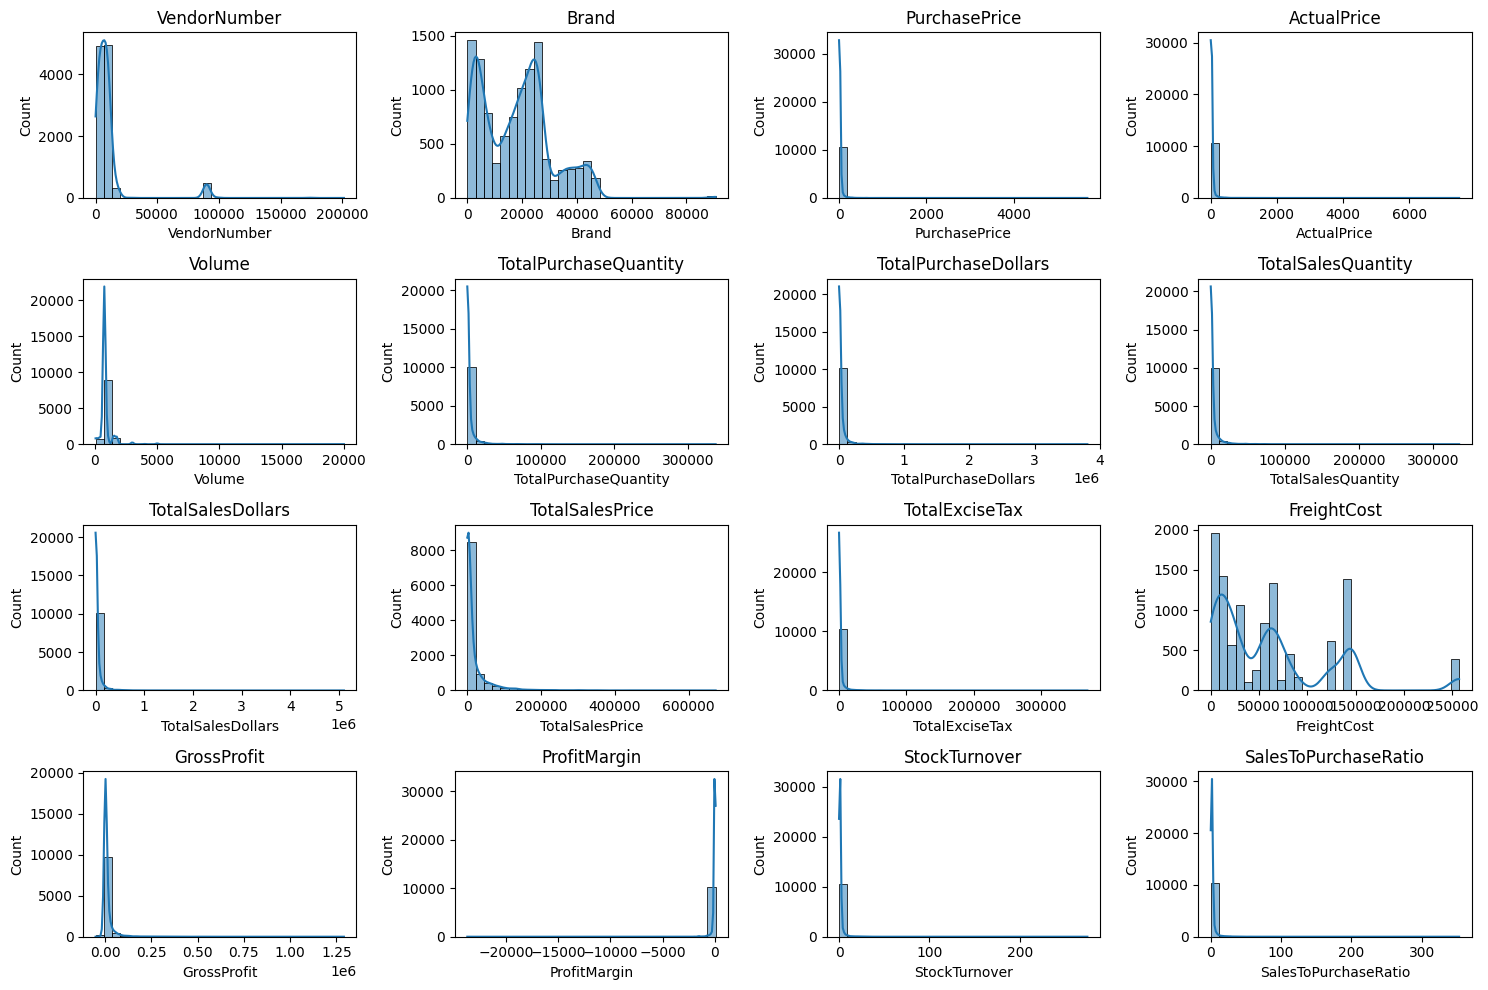

In [52]:
import numpy as np
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

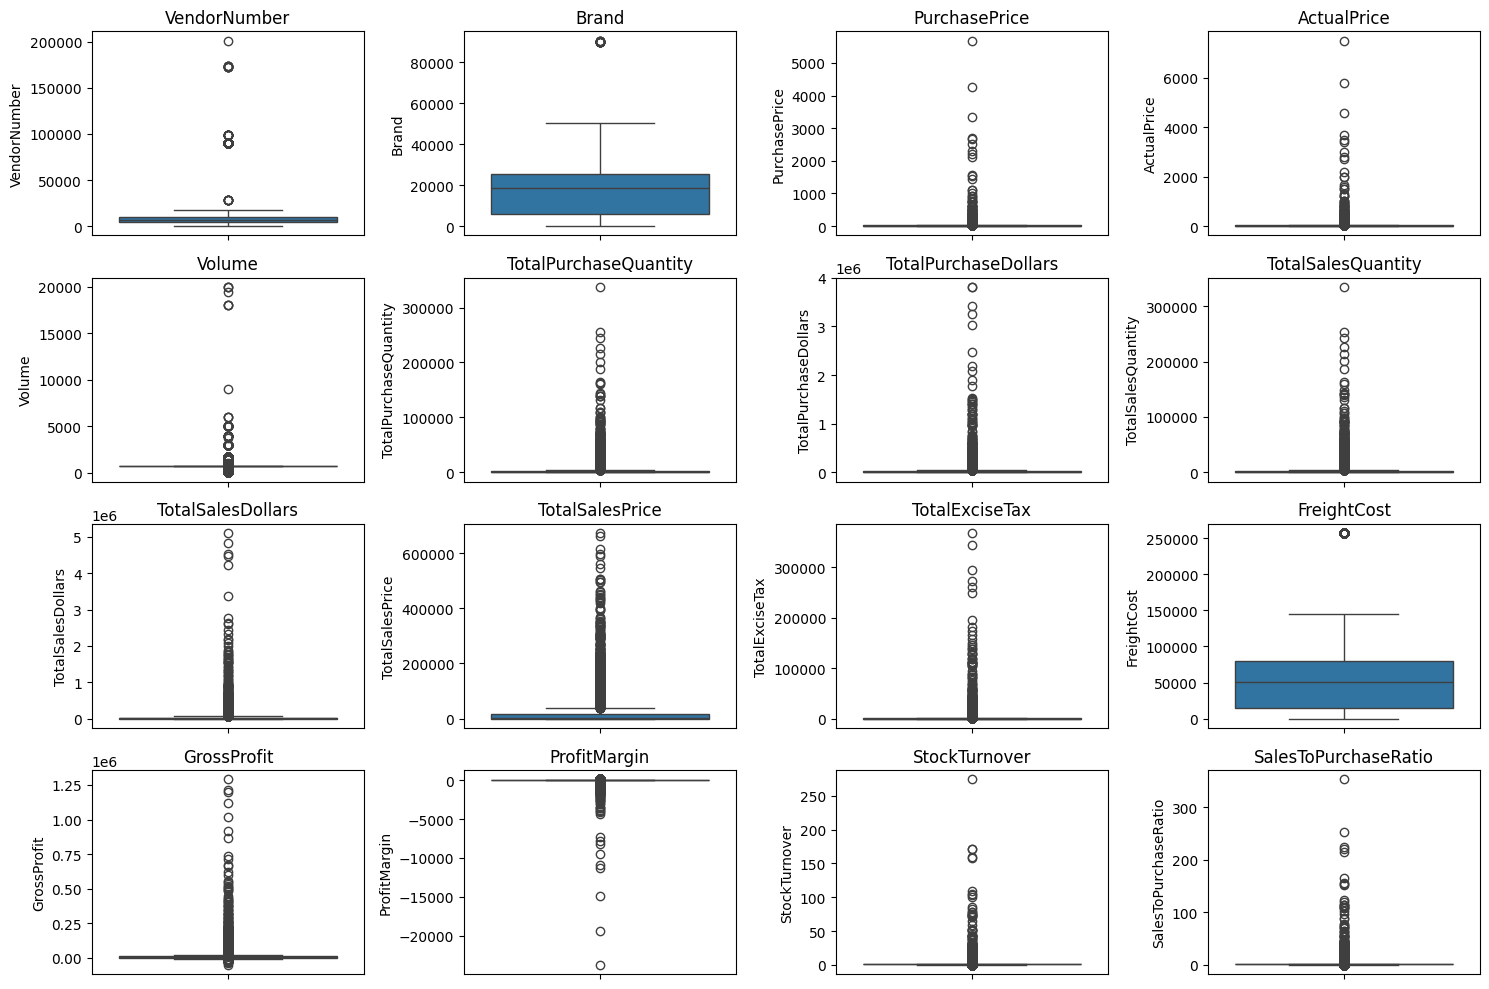

In [53]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

***Summary Statistics Insights***

**Negative & Zero Values:**

* Gross Profit: Minimum value is -52,002.78, including losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
* Profit margin: Has a minimum of - infinity, which suggests cases where revenue is zero or even lower than costs.
* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchass but never sold. These could be slow-moving or obsolete stocks.

**Outliers indicated by High Standard Deviations:**

* Purchases & Actual Prices: The max values (5,681,81 & 7,499,99) are significantly higher than the mean, indicating potential premium products.
* Freight cost: Huge variation, from 0.9 to 257,032,07, suggests logistics inefficiencies or bulk shpments.
* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfiled from older stock.

In [54]:
df = pd.read_sql_query("""select
* from vendor_sales_summary
where GrossProfit > 0
and ProfitMargin > 0
and TotalSalesQuantity > 0
""",conn)

In [55]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


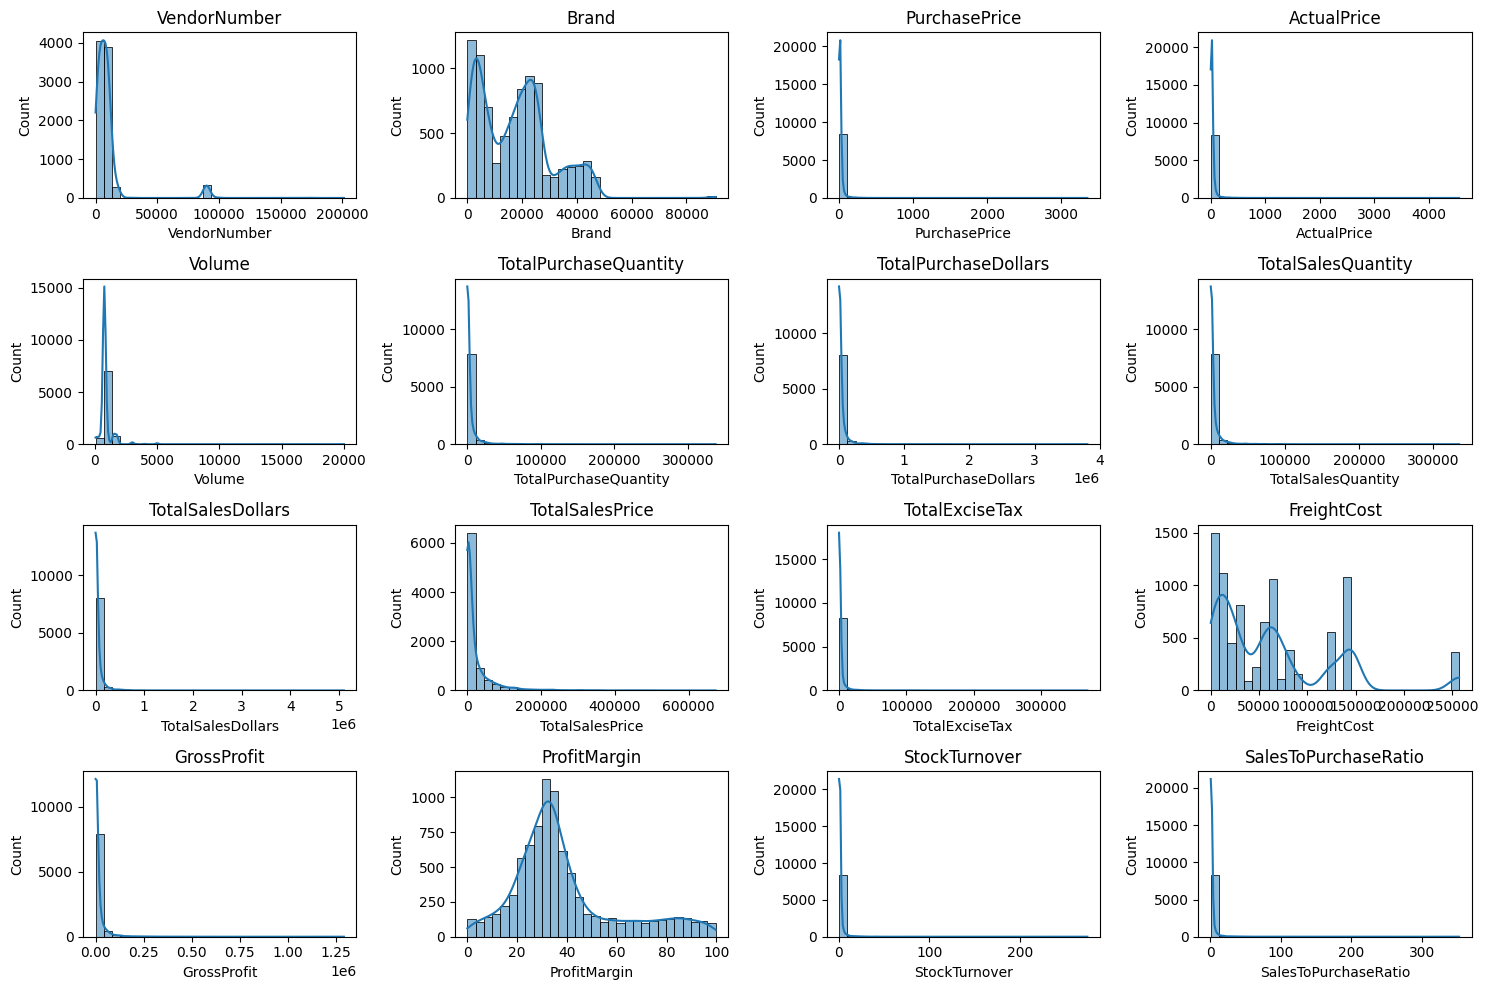

In [56]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

Profit margin graph distribution fixed for 100%

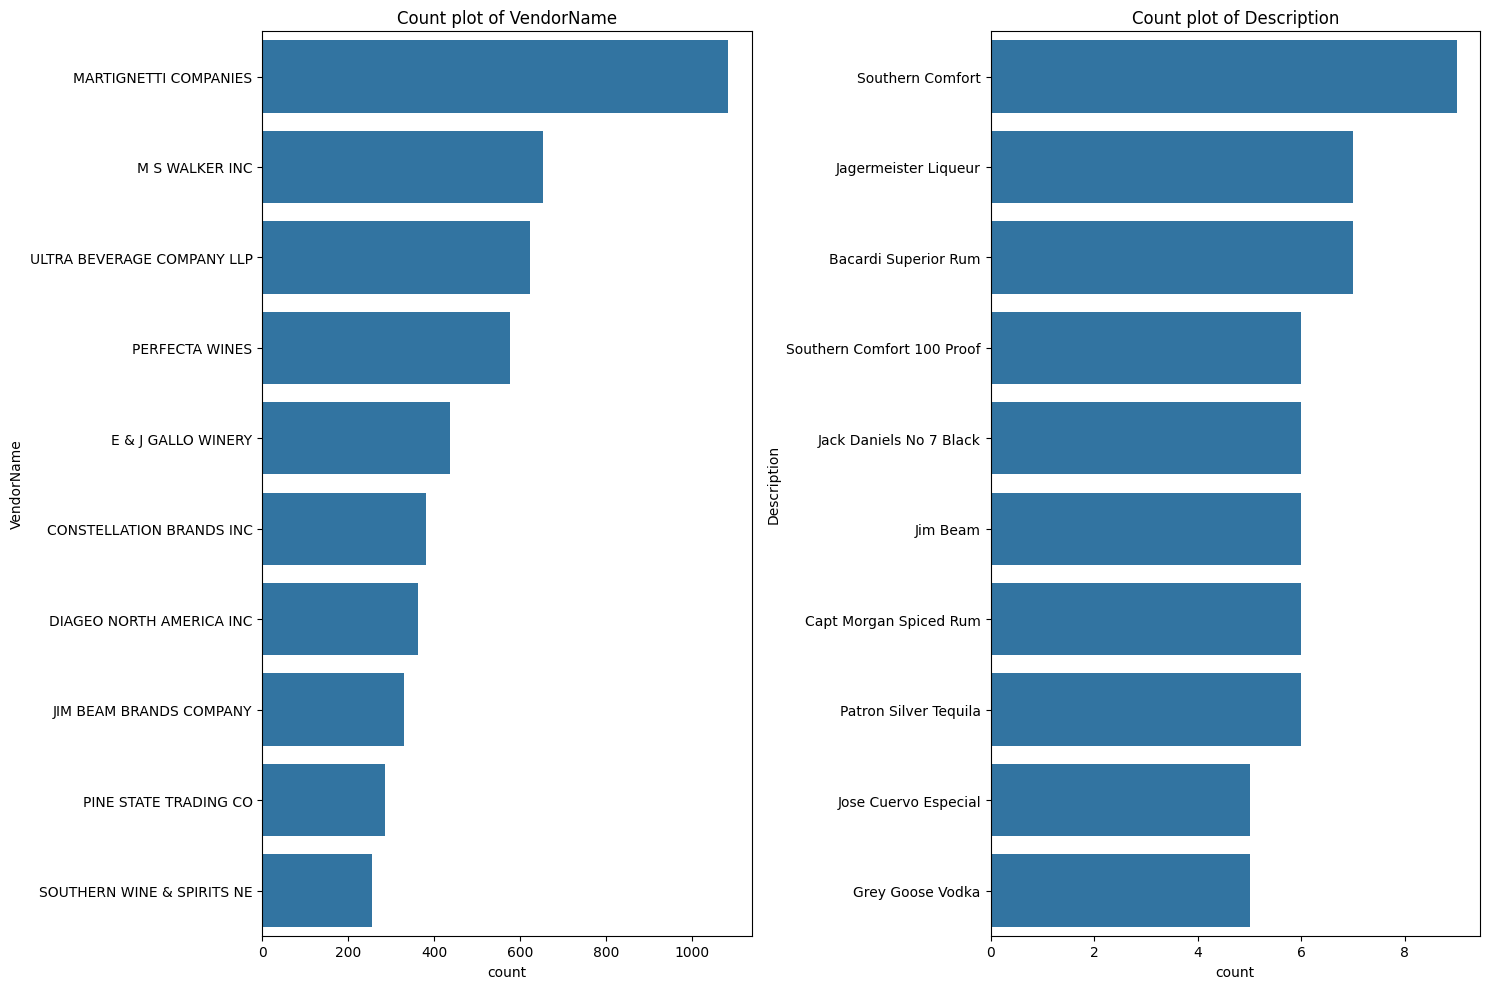

In [57]:
categorical_cols = ['VendorName', 'Description']

plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) #Top 10 categories
    plt.title(f"Count plot of {col}")
plt.tight_layout()
plt.show()

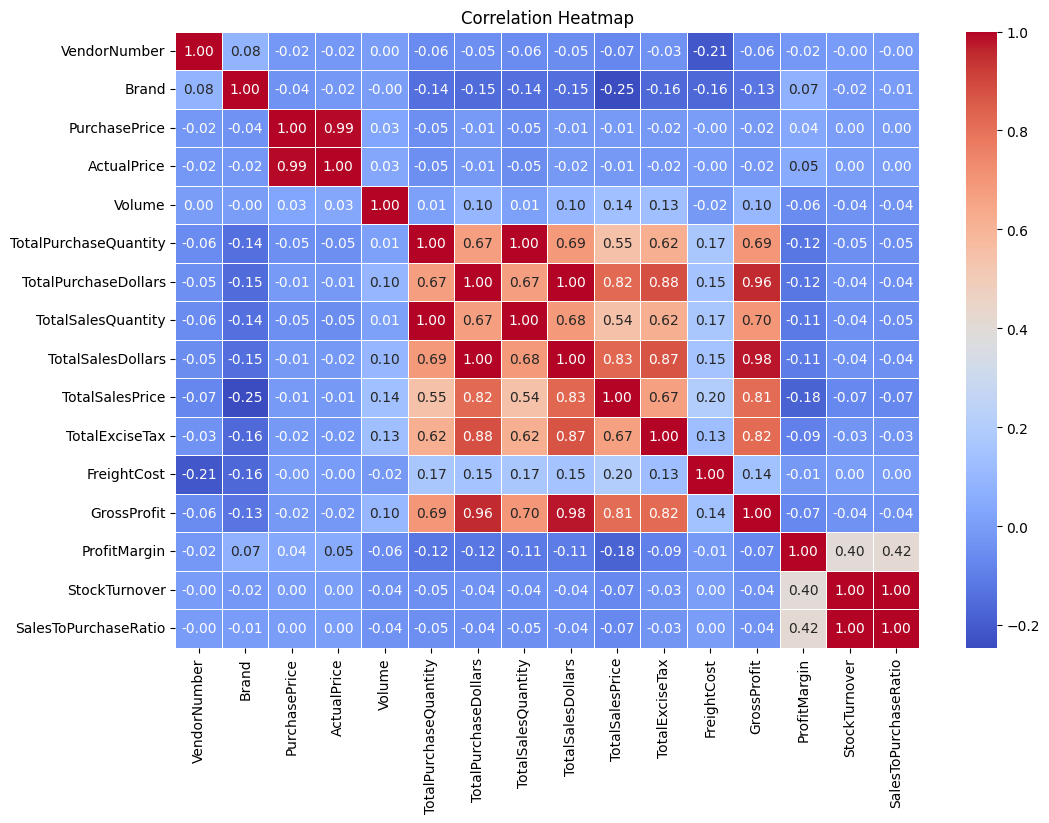

In [58]:
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Very Strong Positive Correlations (≥ 0.80)**


* PurchasePrice ↔ ActualPrice (0.99) — Prices are nearly identical, suggesting minimal markup variation
* TotalPurchaseDollars ↔ TotalSalesDollars (0.82–1.00 cluster) — The entire sales/purchase dollar block moves together tightly
* GrossProfit ↔ TotalSalesDollars (0.98) — Revenue is the primary driver of gross profit
* TotalSalesPrice ↔ TotalExciseTax (0.67) — Higher sales prices attract higher excise taxes


**Moderate Positive Correlations**


* Volume ↔ TotalSalesPrice (0.14) — Weak link between volume and pricing
* FreightCost ↔ Volume (0.17) — Slightly more freight with more volume


**Notable Negative Correlations**


* Brand ↔ TotalSalesPrice (-0.25) — Certain brands are associated with lower sale prices
* ProfitMargin ↔ TotalSalesPrice (-0.18) — Higher sale prices don't necessarily mean better margins


**Near-Zero / Uncorrelated**

* StockTurnover & SalesToPurchaseRatio are almost entirely uncorrelated with most variables, except each other (1.00) — they measure a similar concept

**Conclusion**

The dataset reflects a distribution/wholesale business where volume-driven metrics (quantity, dollars) are tightly coupled, pricing is consistent, but profit margins behave independently — suggesting margin is influenced by factors not fully captured here (e.g., discounts, product mix, brand).

**Analysis**

**Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.**

In [59]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'
}).reset_index()

In [60]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [61]:
low_sales_threshold

np.float64(560.299)

In [62]:
high_margin_threshold

np.float64(64.97017552750111)

In [63]:
target_brands = brand_performance[
(brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
(brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


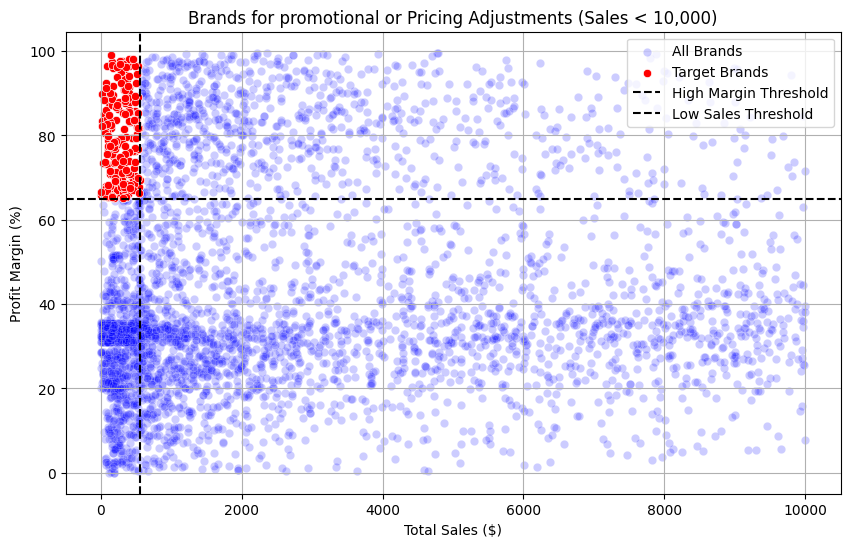

In [64]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance[brand_performance['TotalSalesDollars'] < 10000], x='TotalSalesDollars', y='ProfitMargin', color='blue', label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color='red', label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title("Brands for promotional or Pricing Adjustments (Sales < 10,000)")
plt.legend()
plt.grid(True)
plt.show()

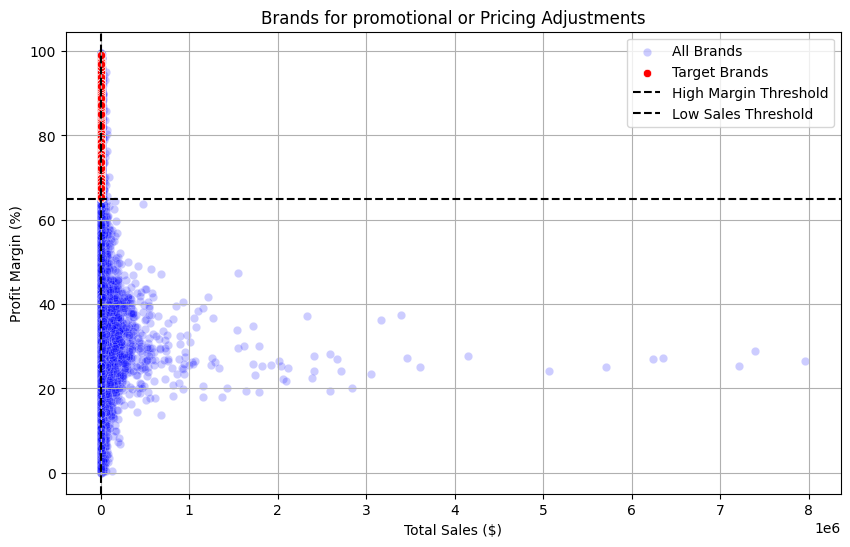

In [65]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color='blue', label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color='red', label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title("Brands for promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

**Which vendors and brands demonstrate the highest sales performance**

In [66]:
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [67]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.933036e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
E & J GALLO WINERY            1.839990e+07
BROWN-FORMAN CORP             1.824723e+07
ULTRA BEVERAGE COMPANY LLP    1.650254e+07
M S WALKER INC                1.470646e+07
Name: TotalSalesDollars, dtype: float64

In [68]:
def format_value(value):
    if value >= 1000000:
        return f"{value / 1000000:.2f}M"
    elif value >= 1000:
        return f"{value / 1000:.2f}K"     
    else:
        return str(value)

top_brands.apply(lambda x: format_value(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

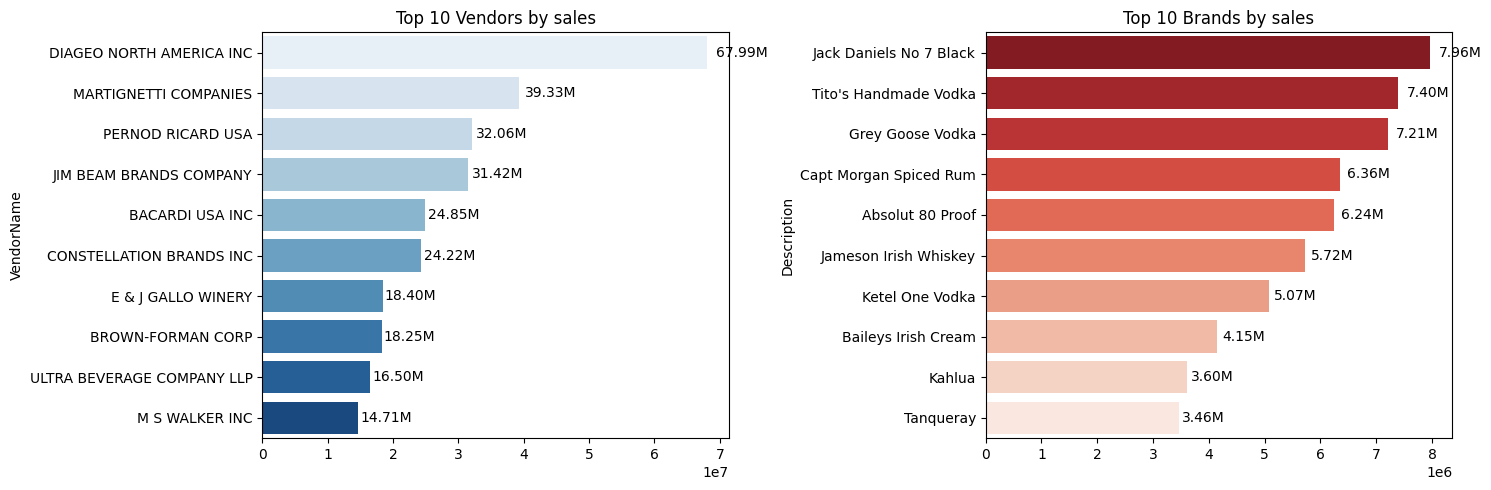

In [69]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues")
plt.title("Top 10 Vendors by sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height() / 2,
            format_value(bar.get_width()),
            ha='left', va='center', fontsize=10, color='black')

plt.subplot(1,2,2)
ax2 = sns.barplot(y=top_brands.index, x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height() / 2,
            format_value(bar.get_width()),
            ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

**Which vendors contribute the most to total purchase dollars?**

In [70]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [71]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum() * 100

In [72]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

In [73]:
top_vendors = vendor_performance.head(10)

top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_value) 
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_value) 
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_value) 

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [74]:
top_vendors['PurchaseContribution%'].sum()

np.float64(65.69000000000001)

top 10 vendors have contributed 66% of total purchase dollars out of all the vendors.

In [75]:
top_vendors['Cumulative_contribution'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_contribution
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


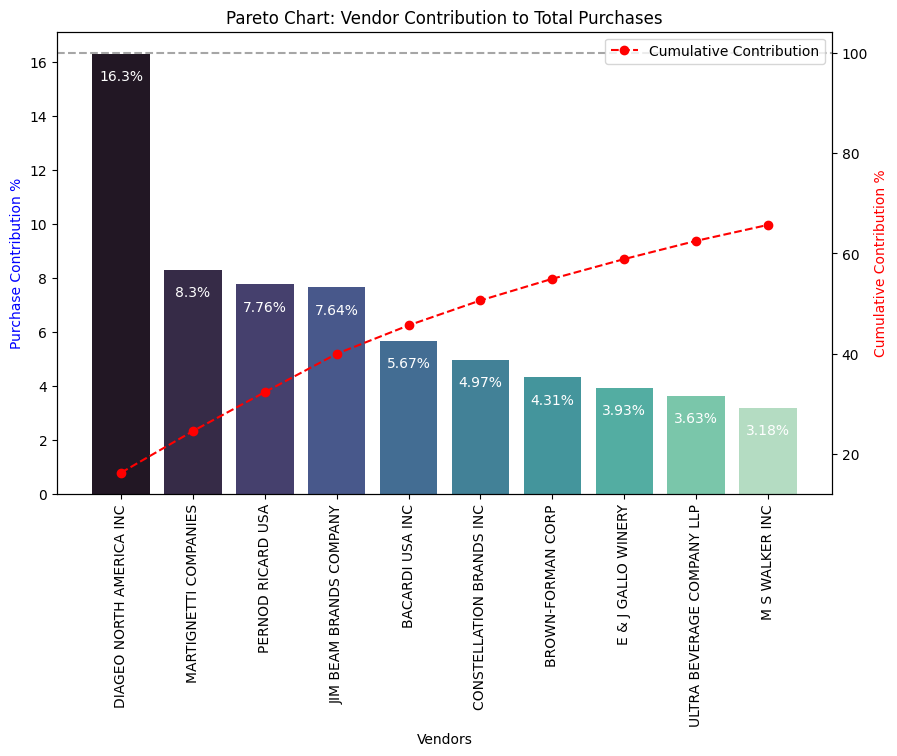

In [76]:
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors ['PurchaseContribution%']):
    ax1.text(i, value-1, str(value) + '%', ha='center', fontsize=10, color="white")

ax2 = ax1.twinx()
ax2.plot(top_vendors ['VendorName'], top_vendors ['Cumulative_contribution'], color='red', marker='o', linestyle='dashed', label='Cumulative Contribution')

ax1.set_xticklabels (top_vendors ['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue') 
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline (y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2. legend (loc='upper right')

plt.show()

**How much of total procurement is depedent on the top vendors?**

In [77]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.69 %


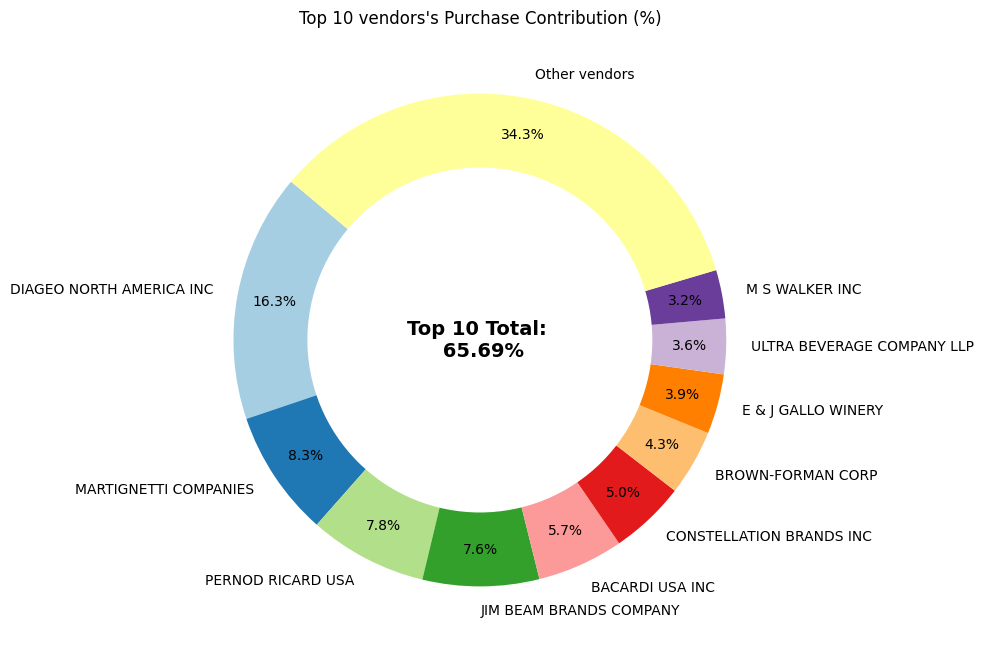

In [78]:
vendors = list(top_vendors['VendorName'].values)
purchase_contribution = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contribution)
remaining_contribution = 100 - total_contribution

vendors.append("Other vendors")
purchase_contribution.append(remaining_contribution)

fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(purchase_contribution, labels=vendors, autopct='%1.1f%%',
                                 startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

plt.text(0,0, f"Top 10 Total: \n {total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 vendors's Purchase Contribution (%)")

plt.show()

**Does purchasung in bulk reduce the unit price, and what is the optimal purchase voluns for cost savings?**

In [79]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [80]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [81]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'],q=3, labels=['Small','Medium','Large'])

In [82]:
df['OrderSize']

0       Large
1       Large
2       Large
3       Large
4       Large
        ...  
8560    Small
8561    Small
8562    Small
8563    Small
8564    Small
Name: OrderSize, Length: 8565, dtype: category
Categories (3, object): ['Small' < 'Medium' < 'Large']

In [83]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8560,Small,2
8561,Small,6
8562,Small,2
8563,Small,1


In [84]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


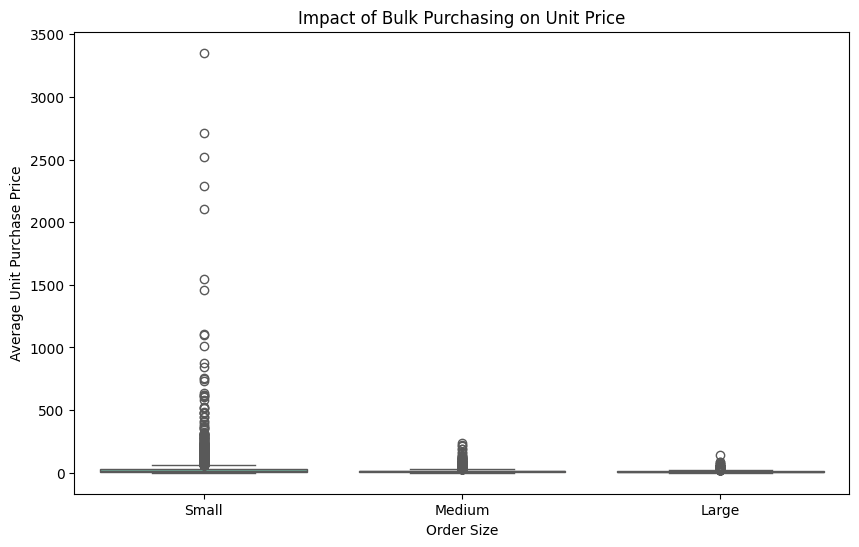

In [85]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

* Vendor buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
* The price differene between Small and Large orders is substantial (~ 72% reduction in unit cost).
* This suggests that bulk pricing strategies successfully encourage vendors to purchase in large volumes, leading to higher overall sales despite lower per-unit revenue.

**Which Vendors have low invetory turnover, indicating excess stock and slow-moving products?**

In [86]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values(by='StockTurnover')

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
...,...
DISARONNO INTERNATIONAL LLC,0.975577
"PREMIUM PORT WINES, INC.",0.976077
TY KU LLC,0.976982


In [87]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values(by='StockTurnover').head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


**How much capital is locked in unsold inventory per vendor, and which vensors contribute th most to it?**

In [88]:
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity']-df['TotalSalesQuantity']) * df['PurchasePrice']
print('Total Unsold Capital: ', format_value(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital:  2.71M


In [89]:
inventory_value_per_vendor = df.groupby("VendorName")[["UnsoldInventoryValue"]].sum().reset_index()

inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_value)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


**What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.**

In [90]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [91]:
top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

In [92]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2142, dtype: float64

In [93]:
low_vendors

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8560    83.448276
8561    96.436186
8562    25.252525
8563    98.974037
8564    99.166079
Name: ProfitMargin, Length: 2142, dtype: float64

In [94]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val-margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


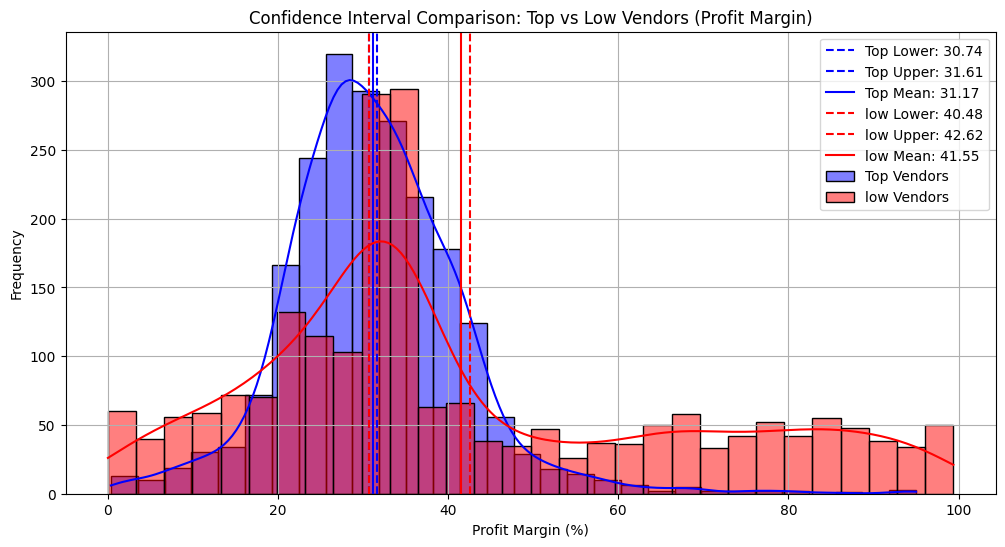

In [95]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12,6))

sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}") 
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}") 
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}") 

sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="low Vendors") 
plt.axvline(top_lower, color="red", linestyle="--", label=f"low Lower: {low_lower:.2f}") 
plt.axvline(low_upper, color="red", linestyle="--", label=f"low Upper: {low_upper:.2f}") 
plt.axvline(low_mean, color="red", linestyle="-", label=f"low Mean: {low_mean:.2f}") 

plt.title("Confidence Interval Comparison: Top vs Low Vendors (Profit Margin)") 
plt.xlabel("Profit Margin (%)") 
plt.ylabel("Frequency") 
plt.legend() 
plt.grid(True) 
plt.show()


* The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%). 
* This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
* For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
* For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.


**Is there a significant difference in profit margins between top-performing and low-performing vendors?**

Hypothesis:

Null Hypothesis: There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

Alternative Hypothesis: The mean profit margins of top-performing and low-performing vendors are significantly different.

In [96]:
top_threshold = df["TotalSalesDollars"].quantile (0.75) 
low_threshold = df["TotalSalesDollars"].quantile (0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna() 
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

#Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print (f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H1: No significant difference in profit margins.")

T-Statistic: -17.6440, P-Value: 0.0000
Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.
